## **Analysis & Visualization**

In [1]:
import pandas as pd
import sys
sys.path.append("..")

from src.analysis import add_basic_location_stats

In [2]:
df_ner = pd.read_pickle("../data/processed/df_ner3.pkl")
df_analysis = add_basic_location_stats(df_ner)

df_analysis["locations"].head(10)

12278    [Pontarlier, Haut-Doubs, Haut-Doubs, de Besanç...
11189    [AUBE   , centrale nucléaire de Nogent, Centra...
13028    [Metz, Metz, Lorraine, circonscription de Metz...
14348    [Villeneuve-St-Georges, Entrepri-, Pays, la Fr...
14268    [Français, République française Jemenin le Pas...
8337     [Carvin Conseiller général, Union, PAS-DE-CALA...
16836    [Touraine, la France, Touraine, la France, SAI...
1130     [Lozère, Lozériens, France, Elus, Usine C A F,...
8350     [Conseiller Général, Régional, SAINT-OMER, Cir...
1138     [Etat, Etat, Etat, Etat, Etat, Etat, circonscr...
Name: locations, dtype: object

In [4]:
from src.analysis import add_clean_locations

df_analysis = add_clean_locations(df_analysis)
df_analysis[["locations", "locations_clean"]].head(10)

,locations,locations_clean
12278,"[Pontarlier, Haut-Doubs, Haut-Doubs, de Besanç...","[Pontarlier, Haut-Doubs, Haut-Doubs, Besançon]"
11189,"[AUBE , centrale nucléaire de Nogent, Centra...","[AUBE, centrale nucléaire de Nogent, Centrale,..."
13028,"[Metz, Metz, Lorraine, circonscription de Metz...","[Metz, Metz, Lorraine, circonscription de Metz..."
14348,"[Villeneuve-St-Georges, Entrepri-, Pays, la Fr...","[Villeneuve-St-Georges, Entrepri-, Pays, Franc..."
14268,"[Français, République française Jemenin le Pas...","[République française Jemenin le Pas Voter, Se..."
8337,"[Carvin Conseiller général, Union, PAS-DE-CALA...","[Carvin Conseiller général, Union, PAS-DE-CALA..."
16836,"[Touraine, la France, Touraine, la France, SAI...","[Touraine, France, Touraine, France, SAINT-CYR..."
1130,"[Lozère, Lozériens, France, Elus, Usine C A F,...","[Lozère, Lozériens, France, Elus, Usine C A F,..."
8350,"[Conseiller Général, Régional, SAINT-OMER, Cir...","[Conseiller Général, Régional, SAINT-OMER, Cir..."
1138,"[Etat, Etat, Etat, Etat, Etat, Etat, circonscr...","[circonscription, LOIRE-ATLANTIQUE, circonscri..."


In [51]:
import pandas as pd

df = pd.read_pickle("../data/processed/df_spatial_analysis.pkl")
locations_ref = pd.read_csv("../data/processed/locations_reference.csv")

df[[
    "departement-nom",
    "locations_clean",
    "classified_locations",
    "local_ratio",
    "national_international_ratio",
    "unknown_ratio",
    "dominant_scale"
]].head(20)

,departement-nom,locations_clean,classified_locations,local_ratio,national_international_ratio,unknown_ratio,dominant_scale
13775,Seine-Maritime,"[Seine-Maritime, France, France, République Française]","[{'location': 'Seine-Maritime', 'scale': 'local'}, {'location': 'France', 'scale': 'national_international'}, {'location': 'France', 'scale': 'national_international'}, {'location': 'République Française', 'scale': 'national_international'}]",0.250000,0.750000,0.000000,national_international
1116,Lot-et-Garonne,"[Agen, Libos, ligne Agen-Penne- Paris, France, France, F LINDENSTAEDT]","[{'location': 'Agen', 'scale': 'local'}, {'location': 'Libos', 'scale': 'unknown'}, {'location': 'ligne Agen-Penne- Paris', 'scale': 'unknown'}, {'location': 'France', 'scale': 'national_international'}, {'location': 'France', 'scale': 'national_international'}, {'location': 'F LINDENSTAEDT', 'scale': 'unknown'}]",0.166667,0.333333,0.500000,national_international
8294,Nord,"[Avesnois, Fivolse, Lille]","[{'location': 'Avesnois', 'scale': 'unknown'}, {'location': 'Fivolse', 'scale': 'unknown'}, {'location': 'Lille', 'scale': 'local'}]",0.333333,0.000000,0.666667,local
4451,Creuse,"[France, France, France, Creuse, Creuse, Creusois, Creuse, Corrèze, Creuse, Millevaches, Creuse, R P R, Creuse, communes de la Creuse, R P R, P M E, CREUSE, CREUSE, Minis-, autoroute Paris-Clermont, Montluçon]","[{'location': 'France', 'scale': 'national_international'}, {'location': 'France', 'scale': 'national_international'}, {'location': 'France', 'scale': 'national_international'}, {'location': 'Creuse', 'scale': 'local'}, {'location': 'Creuse', 'scale': 'local'}, {'location': 'Creusois', 'scale': 'unknown'}, {'location': 'Creuse', 'scale': 'local'}, {'location': 'Corrèze', 'scale': 'national_international'}, {'location': 'Creuse', 'scale': 'local'}, {'location': 'Millevaches', 'scale': 'national_international'}, {'location': 'Creuse', 'scale': 'local'}, {'location': 'R P R', 'scale': 'unknown'}, {'location': 'Creuse', 'scale': 'local'}, {'location': 'communes de la Creuse', 'scale': 'unknown'}, {'location': 'R P R', 'scale': 'unknown'}, {'location': 'P M E', 'scale': 'unknown'}, {'location': 'CREUSE', 'scale': 'local'}, {'location': 'CREUSE', 'scale': 'local'}, {'location': 'Minis-', 'scale': 'unknown'}, {'location': 'autoroute Paris-Clermont', 'scale': 'unknown'}, {'location': 'Montluçon', 'scale': 'national_international'}]",0.380952,0.285714,0.333333,local
4622,Finistère,"[Centre Bretagne, Trégor, Angleterre, Allemagne, Portugal, Kerfraval, Launay, Conseil Général, Centrales Nucléaires]","[{'location': 'Centre Bretagne', 'scale': 'unknown'}, {'location': 'Trégor', 'scale': 'unknown'}, {'location': 'Angleterre', 'scale': 'unknown'}, {'location': 'Allemagne', 'scale': 'unknown'}, {'location': 'Portugal', 'scale': 'unknown'}, {'location': 'Kerfraval', 'scale': 'unknown'}, {'location': 'Launay', 'scale': 'national_international'}, {'location': 'Conseil Général', 'scale': 'local'}, {'location': 'Centrales Nucléaires', 'scale': 'unknown'}]",0.111111,0.111111,0.777778,national_international
4469,Dordogne,"[P C - P S IL, NUCLEAIRE, France, Païs, BERGERAC]","[{'location': 'P C - P S IL', 'scale': 'unknown'}, {'location': 'NUCLEAIRE', 'scale': 'unknown'}, {'location': 'France', 'scale': 'national_international'}, {'location': 'Païs', 'scale': 'unknown'}, {'location': 'BERGERAC', 'scale': 'local'}]",0.200000,0.200000,0.600000,national_international
5956,Pas-de-Calais,"[l'Europe, France, Lille, Sébastopol, Paris]","[{'location': 'l'Europe', 'scale': 'unknown'}, {'location': 'France', 'scale': 'national_international'}, {'location': 'Lille', 'scale': 'national_international'}, {'location': 'Sébastopol', 'scale': 'unknown'}, {'location': 'Paris', 'scale': 'national_international'}]",0.000000,0.600000,0.400000,national_international
12713,Loire,"[Centre, Soutien, FRANCE, Roannais, autoroute Balbigny-Lyon, Pont, Pays, FRANCE, FRANCE DE L'AMBITION POUR LE ROANNAIS, Centre, Région E

In [52]:
locations_ref[[
    "location",
    "country",
    "country_code",
    "county",
    "state",
    "display_name",
    "geo_class",
    "geo_type"
]].head(10)

,location,country,country_code,county,state,display_name,geo_class,geo_type
0,Seine-Maritime,France,fr,Seine-Maritime,Normandie,"Seine-Maritime, Normandie, France métropolitaine, France",boundary,administrative
1,France,France,fr,NaN,NaN,France,boundary,administrative
2,République Française,France,fr,NaN,NaN,France,boundary,administrative
3,Agen,France,fr,Lot-et-Garonne,Nouvelle-Aquitaine,"Agen, Lot-et-Garonne, Nouvelle-Aquitaine, France métropolitaine, 47000, France",boundary,administrative
4,Libos,France,fr,Lot-et-Garonne,Nouvelle-Aquitaine,"Libos, Monsempron-Libos, Villeneuve-sur-Lot, Lot-et-Garonne, Nouvelle-Aquitaine, France métropolitaine, 47500, France",place,hamlet
5,ligne Agen-Penne- Paris,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,F LINDENSTAEDT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Avesnois,France,fr,Nord,Hauts-de-France,"Neuville-en-Avesnois, Avesnes-sur-Helpe, Nord, Hauts-de-France, France métropolitaine, 59218, France",boundary,administrative
8,Fivolse,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Lille,France,fr,Nord,Hauts-de-France,"Lille, Nord, Hauts-de-France, France métropolitaine, France",boundary,administrative


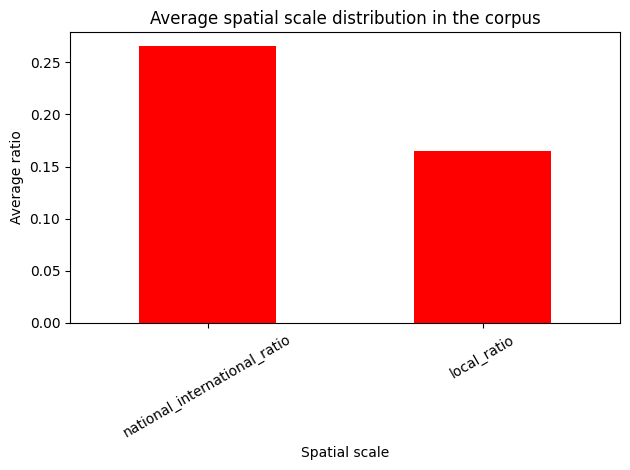

In [53]:
import matplotlib.pyplot as plt

scale_means = df[[
    "local_ratio",
    "national_international_ratio"
]].mean().sort_values(ascending=False)

scale_means.plot(kind="bar", color="red")

plt.title("Average spatial scale distribution in the corpus")
plt.ylabel("Average ratio")
plt.xlabel("Spatial scale")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

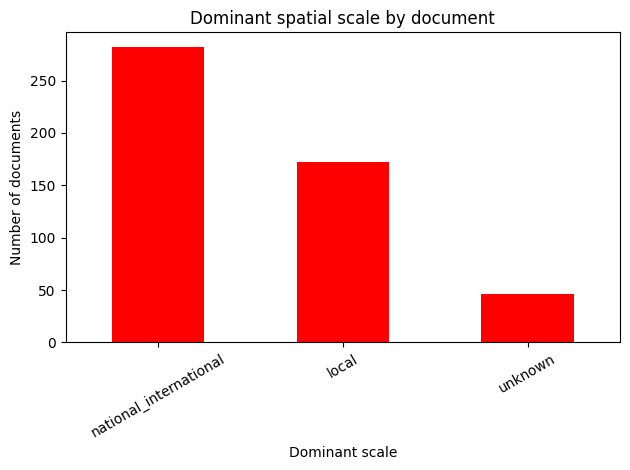

In [54]:
df["dominant_scale"].value_counts().plot(kind="bar", color="red")

plt.title("Dominant spatial scale by document")
plt.ylabel("Number of documents")
plt.xlabel("Dominant scale")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

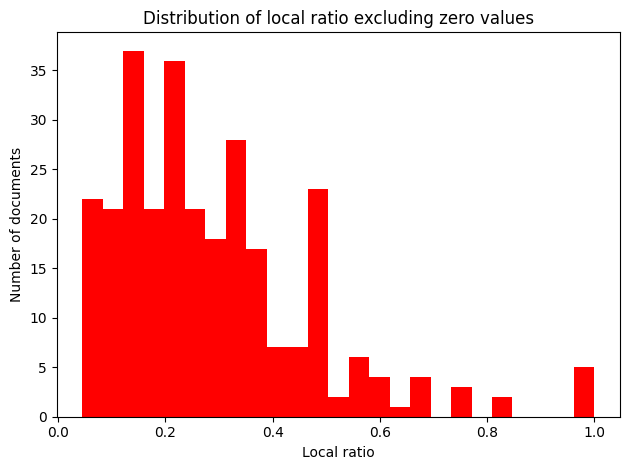

In [55]:
local_nonzero = df[df["local_ratio"] > 0]["local_ratio"]

local_nonzero.plot(kind="hist", bins=25, color="red")

plt.title("Distribution of local ratio excluding zero values")
plt.xlabel("Local ratio")
plt.ylabel("Number of documents")
plt.tight_layout()
plt.show()

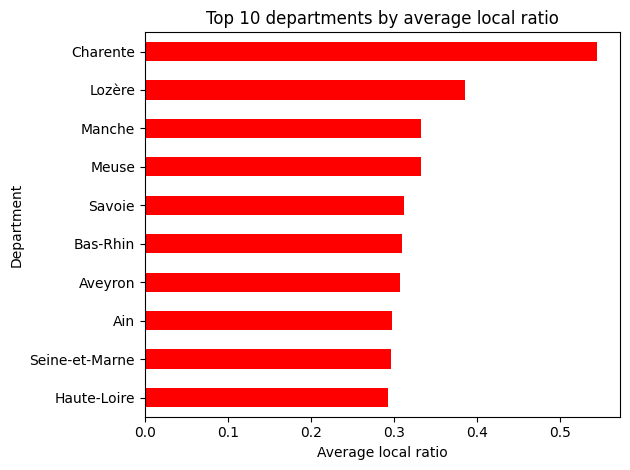

In [56]:
dept_local = (
    df.groupby("departement-nom")["local_ratio"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

dept_local.plot(kind="barh", color="red")

plt.title("Top 10 departments by average local ratio")
plt.xlabel("Average local ratio")
plt.ylabel("Department")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

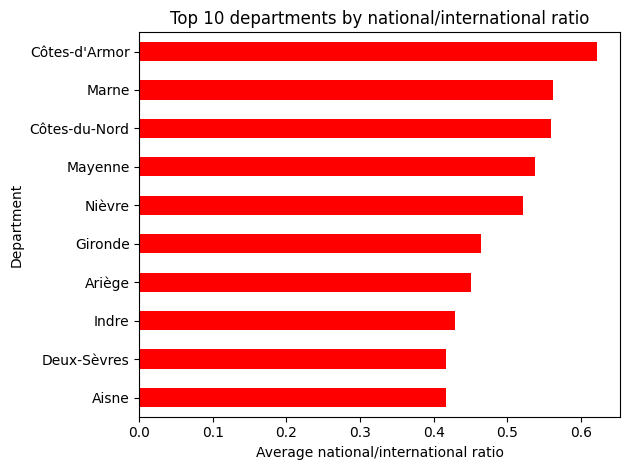

In [57]:
dept_nonlocal = (
    df.groupby("departement-nom")["national_international_ratio"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

dept_nonlocal.plot(kind="barh", color="red")

plt.title("Top 10 departments by national/international ratio")
plt.xlabel("Average national/international ratio")
plt.ylabel("Department")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

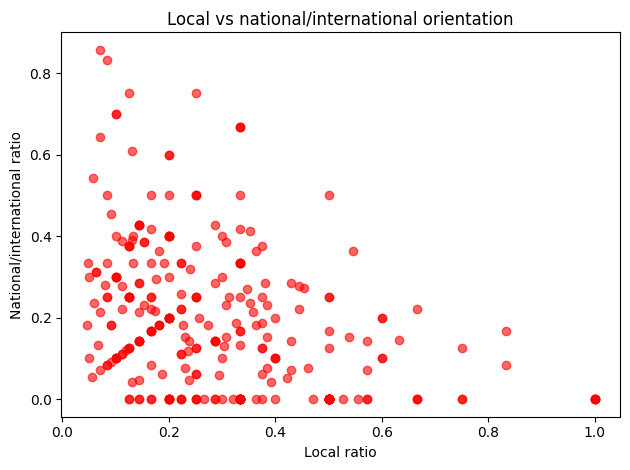

In [58]:
df_plot = df[df["local_ratio"] > 0]

plt.scatter(
    df_plot["local_ratio"],
    df_plot["national_international_ratio"],
    alpha=0.6,
    color="red"
)

plt.title("Local vs national/international orientation")
plt.xlabel("Local ratio")
plt.ylabel("National/international ratio")
plt.tight_layout()
plt.show()

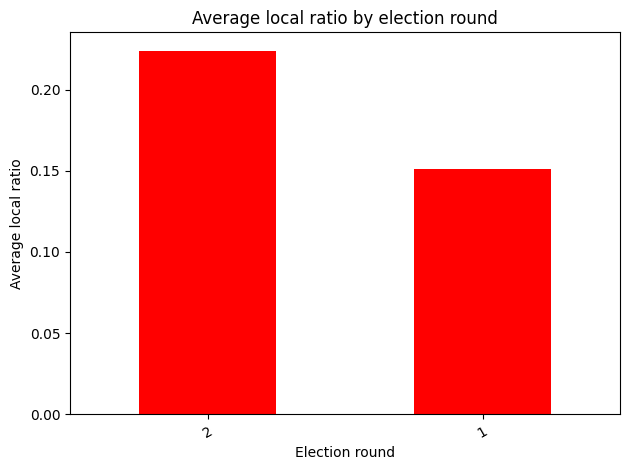

In [59]:
tour_local = (
    df.groupby("contexte-tour")["local_ratio"]
    .mean()
    .sort_values(ascending=False)
)

tour_local.plot(kind="bar", color="red")

plt.title("Average local ratio by election round")
plt.ylabel("Average local ratio")
plt.xlabel("Election round")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

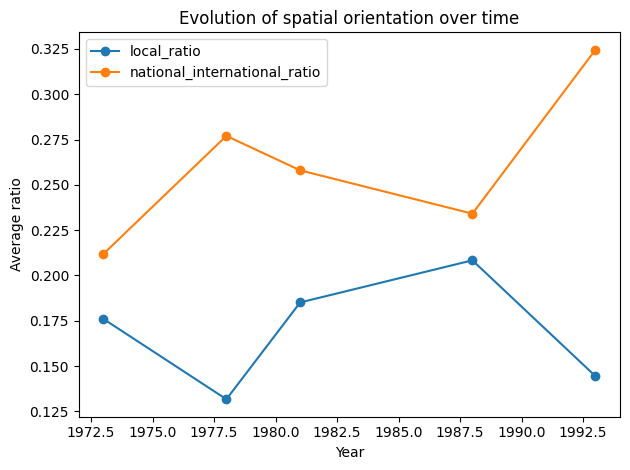

In [60]:
df["year"] = pd.to_datetime(df["date"], errors="coerce").dt.year

year_local = df.groupby("year")[
    ["local_ratio", "national_international_ratio"]
].mean()

year_local.plot(kind="line", marker="o")

plt.title("Evolution of spatial orientation over time")
plt.ylabel("Average ratio")
plt.xlabel("Year")
plt.tight_layout()
plt.show()